# EC523 Project — Speech Denoising

Tamerlan Baimurat, Punnisa Amornsirikul, Jiaxing Wang, Michael Lwe

{baimurat, punnisa, jiaxingw, mlwe}@bu.edu

Spring 2026


**Dataset:** 23,075 training + 824 test paired clean/noisy utterances (16 kHz, mono).
All audio has been preprocessed to complex STFT tensors (`complex64`, shape `[257, T]`) and served via a public HTTP endpoint: https://ec523.tamerlanbaimurat.com.

**Goal:** Build and train a neural network that takes a noisy STFT spectrogram as input and produces a denoised (clean) spectrogram as output.

# 1. Setup

This section loads all required libaries for our project.

In [ ]:
!pip install flash-linear-attention

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.7/284.7 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.2/510.2 kB 45.0 MB/s eta 0:00:00


In [ ]:
from __future__ import print_function
import io
import json
import os
import random
import threading
import time
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import requests
from requests.adapters import HTTPAdapter
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from fla.layers import DeltaNet

In [ ]:
# def set_seed(seed: int = 42) -> None:
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed_all(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False
#     os.environ["PYTHONHASHSEED"] = str(seed)
#     print(f"Random seed set to {seed}")

# set_seed(42)

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Device: {device}")

Random seed set to 42
Device: cuda


# 2. Retrieving Data

The following Python script retrives the training and testing dataset from our HTML endpoint, https://ec523.tamerlanbaimurat.com.

In [ ]:
BASE_URL = "https://ec523.tamerlanbaimurat.com"
PREFIX   = "ec523project"
MAX_RETRIES = 5

def public_url(key: str) -> str:
    return f"{BASE_URL}/{quote(key.lstrip('/'), safe='/')}"

_local = threading.local()

def _session() -> requests.Session:
    if not hasattr(_local, "s"):
        s = requests.Session()
        adapter = HTTPAdapter(pool_connections=64, pool_maxsize=64)
        s.mount("https://", adapter)
        _local.s = s
    return _local.s

def fetch_bytes(key: str, timeout: int = 60) -> bytes:
    for attempt in range(MAX_RETRIES):
        try:
            r = _session().get(public_url(key), timeout=timeout)
            if r.status_code == 503:
                raise requests.exceptions.ConnectionError("503")
            r.raise_for_status()
            return r.content
        except (requests.exceptions.ConnectionError,
                requests.exceptions.Timeout,
                requests.exceptions.HTTPError):
            if attempt == MAX_RETRIES - 1:
                raise
            time.sleep(2 ** attempt + random.random())
    return b""

def fetch_manifest(split: str) -> list[dict]:
    key = f"{PREFIX}/manifests/{split}.jsonl"
    text = fetch_bytes(key).decode()
    return [json.loads(line) for line in text.splitlines() if line.strip()]


class AdaptivePool:
    """AIMD concurrency: starts fast, backs off on 503, recovers quickly."""

    def __init__(self, initial=32, minimum=4, maximum=64, grow_every=20):
        self._sem_value = initial
        self._sem = threading.Semaphore(initial)
        self._lock = threading.Lock()
        self._min = minimum
        self._max = maximum
        self._grow_every = grow_every
        self.successes = 0
        self.errors = 0

    @property
    def window(self):
        return self._sem_value

    def acquire(self):
        self._sem.acquire()

    def release_success(self):
        with self._lock:
            self.successes += 1
            if self.successes % self._grow_every == 0 and self._sem_value < self._max:
                self._sem_value += 1
                self._sem.release()
                return
        self._sem.release()

    def release_error(self):
        with self._lock:
            self.errors += 1
            new = max(self._sem_value // 2, self._min)
            while self._sem_value > new:
                self._sem.acquire(blocking=False) or None
                self._sem_value -= 1
        self._sem.release()


class STFTDataset(Dataset):
    """Fetches clean/noisy STFT pairs from HTTP, with in-memory caching."""

    def __init__(self, records: list[dict], split: str):
        self.records = records
        self.split = split
        self._cache: dict[int, tuple[torch.Tensor, torch.Tensor]] = {}

    @classmethod
    def from_manifest(cls, split: str) -> "STFTDataset":
        records = fetch_manifest(split)
        print(f"[{split}] manifest loaded: {len(records)} pairs")
        return cls(records, split)

    def prefetch_all(self):
        """Download every pair into RAM with adaptive concurrency."""
        from concurrent.futures import ThreadPoolExecutor, as_completed

        to_fetch = [i for i in range(len(self.records)) if i not in self._cache]
        if not to_fetch:
            print(f"[{self.split}] all {len(self.records)} pairs already cached")
            return

        pool = AdaptivePool(initial=32, minimum=4, maximum=128)

        def _download(idx):
            pool.acquire()
            try:
                rec = self.records[idx]
                noisy_bytes = fetch_bytes(rec["noisy_stft_key"])
                clean_bytes = fetch_bytes(rec["clean_stft_key"])
                noisy = torch.load(io.BytesIO(noisy_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                clean = torch.load(io.BytesIO(clean_bytes), map_location="cpu",
                                   weights_only=True)["stft"]
                pool.release_success()
                return idx, noisy, clean
            except Exception:
                pool.release_error()
                raise

        print(f"[{self.split}] prefetching {len(to_fetch)} pairs "
              f"(adaptive window: {pool.window}→{pool._max}) …")
        t0 = time.perf_counter()
        done, errors = 0, 0

        # Use a large thread pool; AdaptivePool's semaphore controls actual concurrency
        with ThreadPoolExecutor(max_workers=64) as ex:
            futures = {ex.submit(_download, i): i for i in to_fetch}
            for fut in as_completed(futures):
                try:
                    idx, noisy, clean = fut.result()
                    self._cache[idx] = (noisy, clean)
                    done += 1
                except Exception as e:
                    errors += 1
                    if errors <= 3:
                        print(f"  ERROR idx={futures[fut]}: {e}")
                total = done + errors
                if total % 500 == 0 or total == len(to_fetch):
                    elapsed = time.perf_counter() - t0
                    print(f"  {total}/{len(to_fetch)}  {elapsed:.0f}s  "
                          f"{done/max(elapsed,1):.0f} pairs/s  "
                          f"window={pool.window}  errors={errors}")
        elapsed = time.perf_counter() - t0
        print(f"[{self.split}] prefetch done: {done} OK, {errors} errors, "
              f"{elapsed:.0f}s")

        # Sequential retry for any failures
        remaining = [i for i in to_fetch if i not in self._cache]
        if remaining:
            print(f"[{self.split}] retrying {len(remaining)} failures …")
            for idx in remaining:
                try:
                    _, noisy, clean = _download(idx)
                    self._cache[idx] = (noisy, clean)
                except Exception as e:
                    print(f"  SKIP idx={idx}: {e}")

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        rec = self.records[idx]

        if idx in self._cache:
            noisy, clean = self._cache[idx]
        else:
            noisy = torch.load(io.BytesIO(fetch_bytes(rec["noisy_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            clean = torch.load(io.BytesIO(fetch_bytes(rec["clean_stft_key"])),
                               map_location="cpu", weights_only=True)["stft"]
            self._cache[idx] = (noisy, clean)

        return {
            "pair_id":     rec["pair_id"],
            "split":       self.split,
            "sample_rate": int(rec["sample_rate"]),
            "noisy":       noisy,          # complex64 [257, T]
            "clean":       clean,          # complex64 [257, T]
            "length":      noisy.shape[-1],
        }

In [ ]:
train_ds = STFTDataset.from_manifest("train")


# Download all data into RAM (~30.5 GB for 23K pairs).
# This takes 500 seconds to fetch
train_ds.prefetch_all()


[train] manifest loaded: 23075 pairs
[test] manifest loaded: 824 pairs
[train] prefetching 23075 pairs (adaptive window: 32→128) …
  500/23075  7s  74 pairs/s  window=57  errors=0
  1000/23075  13s  80 pairs/s  window=82  errors=0
  1500/23075  18s  82 pairs/s  window=107  errors=0
  2000/23075  24s  84 pairs/s  window=128  errors=0
  2500/23075  30s  85 pairs/s  window=128  errors=0
  3000/23075  35s  85 pairs/s  window=128  errors=0
  3500/23075  41s  86 pairs/s  window=128  errors=0
  4000/23075  46s  87 pairs/s  window=128  errors=0
  4500/23075  51s  87 pairs/s  window=128  errors=0
  5000/23075  57s  88 pairs/s  window=128  errors=0
  5500/23075  63s  88 pairs/s  window=128  errors=0
  6000/23075  68s  88 pairs/s  window=128  errors=0
  6500/23075  74s  88 pairs/s  window=128  errors=0
  7000/23075  79s  89 pairs/s  window=128  errors=0
  7500/23075  84s  89 pairs/s  window=128  errors=0
  8000/23075  90s  89 pairs/s  window=128  errors=0
  8500/23075  95s  89 pairs/s  window=128

In [ ]:
test_ds  = STFTDataset.from_manifest("test")
test_ds.prefetch_all()

[test] manifest loaded: 824 pairs
[test] prefetching 824 pairs (adaptive window: 32→128) …
  500/824  12s  40 pairs/s  window=57  errors=0
  824/824  21s  40 pairs/s  window=73  errors=0
[test] prefetch done: 824 OK, 0 errors, 21s


# 3. Data Helpers & DataLoaders

Utilities for converting complex STFT to magnitude/phase, collating variable-length batches, and creating DataLoaders.

In [ ]:
def stft_to_mag_phase(stft_complex):
    mag = stft_complex.abs()
    phase = stft_complex.angle()
    return mag, phase

In [ ]:
TIME_BUCKETS = [100, 200, 300, 400, 500, 600, 800, 1000, 1200, 1600]

def _bucket_pad(t: int) -> int:
    """Round up to the nearest bucket size so Triton sees fewer unique shapes."""
    for b in TIME_BUCKETS:
        if t <= b:
            return b
    return ((t + 63) // 64) * 64

def collate_magnitude(batch):
    """
    Custom collate that converts complex STFTs to log-magnitude tensors
    and pads to a fixed bucket size (reduces Triton recompilations).

    Returns dict with keys:
        noisy_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        clean_mag:   [B, 1, 257, T_bucket]  log1p magnitude
        noisy_phase: [B, 257, T_bucket]     phase (for reconstruction)
        lengths:     [B]                     original T per sample
        pair_ids:    list[str]
    """
    max_t = max(item["noisy"].shape[-1] for item in batch)
    pad_to = _bucket_pad(max_t)

    noisy_mags, clean_mags, noisy_phases, lengths, pair_ids = [], [], [], [], []

    for item in batch:
        n_mag, n_phase = stft_to_mag_phase(item["noisy"])
        c_mag, _       = stft_to_mag_phase(item["clean"])

        pad_t = pad_to - n_mag.shape[-1]
        n_mag   = F.pad(n_mag, (0, pad_t))
        c_mag   = F.pad(c_mag, (0, pad_t))
        n_phase = F.pad(n_phase, (0, pad_t))

        noisy_mags.append(torch.log1p(n_mag).unsqueeze(0))   # [1, 257, T]
        clean_mags.append(torch.log1p(c_mag).unsqueeze(0))
        noisy_phases.append(n_phase)
        lengths.append(item["length"])
        pair_ids.append(item["pair_id"])

    return {
        "noisy_mag":   torch.stack(noisy_mags),     # [B, 1, 257, T]
        "clean_mag":   torch.stack(clean_mags),      # [B, 1, 257, T]
        "noisy_phase": torch.stack(noisy_phases),    # [B, 257, T]
        "lengths":     torch.tensor(lengths, dtype=torch.int64),
        "pair_ids":    pair_ids,
    }

Creates trainloader and testloader DataLoader objects in batches of BATCH_SIZE, which is currently set to 8.

In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_magnitude,
    num_workers=0,   # required: HTTP session is not picklable
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_magnitude,
    num_workers=0,
)

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")

Train: 23075 samples, 2885 batches
Test:  824 samples, 103 batches


Here we print some information about our data, with an example spectrogram for reference.

Batch keys: ['noisy_mag', 'clean_mag', 'noisy_phase', 'lengths', 'pair_ids']
noisy_mag  : torch.Size([8, 1, 257, 719])  dtype=torch.float32
clean_mag  : torch.Size([8, 1, 257, 719])  dtype=torch.float32
noisy_phase: torch.Size([8, 257, 719])
lengths    : tensor([175, 272, 719, 625, 511, 396, 416, 277])
pair_ids   : ['p232_001', 'p232_002', 'p232_003', 'p232_005', 'p232_006', 'p232_007', 'p232_009', 'p232_010']


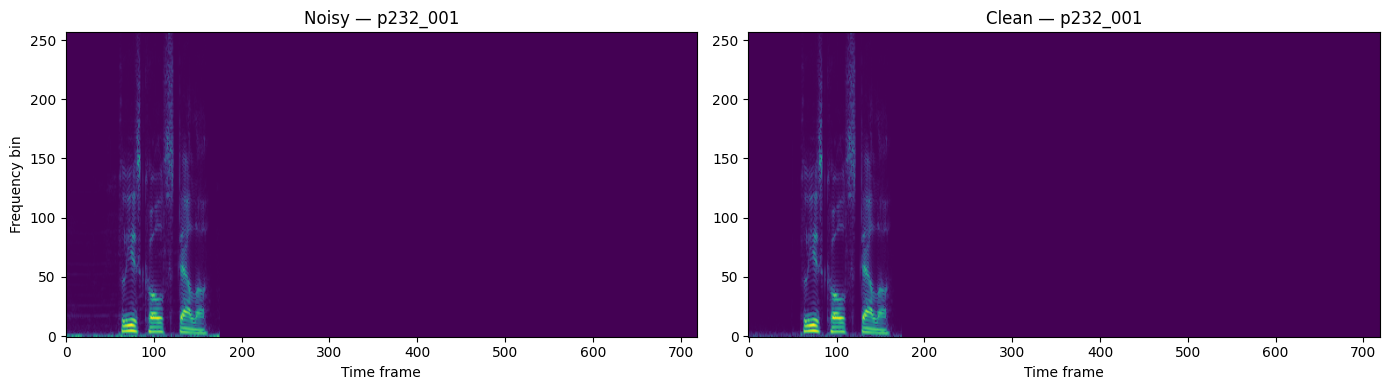

In [ ]:

batch = next(iter(test_loader))

print("Batch keys:", list(batch.keys()))
print(f"noisy_mag  : {batch['noisy_mag'].shape}  dtype={batch['noisy_mag'].dtype}")
print(f"clean_mag  : {batch['clean_mag'].shape}  dtype={batch['clean_mag'].dtype}")
print(f"noisy_phase: {batch['noisy_phase'].shape}")
print(f"lengths    : {batch['lengths']}")
print(f"pair_ids   : {batch['pair_ids']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
idx = 0
axes[0].imshow(batch["noisy_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[0].set_title(f"Noisy — {batch['pair_ids'][idx]}")
axes[0].set_xlabel("Time frame")
axes[0].set_ylabel("Frequency bin")
axes[1].imshow(batch["clean_mag"][idx, 0].numpy(), aspect="auto", origin="lower")
axes[1].set_title(f"Clean — {batch['pair_ids'][idx]}")
axes[1].set_xlabel("Time frame")
plt.tight_layout()
plt.show()

# 4. Model Architecture

This section details the code for the architecture of our model. [Expand on this later]

Input: `noisy_mag [B, 1, 257, T]` (log-magnitude spectrogram)

Output: predicted clean magnitude (same shape), or a mask in `[0, 1]`

STFT parameters: `n_fft=512`, `hop_length=160`, `win_length=400`, `window=hann`, 257 frequency bins.

In [ ]:
from torch.utils.checkpoint import checkpoint as grad_checkpoint

# ---------------------------------------------------------------------------
# Building blocks
# ---------------------------------------------------------------------------

class ConvBlock(nn.Module):
    """Conv2d -> BatchNorm -> PReLU. Optionally downsamples frequency via stride."""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=(1, 1), padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_ch),
            nn.PReLU(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class DeconvBlock(nn.Module):
    """ConvTranspose2d -> BatchNorm -> PReLU. Upsamples frequency via stride."""
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=(2, 1),
                 padding=1, output_padding=(1, 0)):
        super().__init__()
        self.block = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, stride=stride,
                               padding=padding, output_padding=output_padding),
            nn.BatchNorm2d(out_ch),
            nn.PReLU(out_ch),
        )

    def forward(self, x):
        return self.block(x)


# ---------------------------------------------------------------------------
# Attention blocks
# ---------------------------------------------------------------------------

class DeltaNetBlock(nn.Module):
    """Pre-norm DeltaNet attention + FFN with residual connections."""
    def __init__(self, d_model, num_heads, ffn_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = DeltaNet(
            d_model=d_model,
            num_heads=num_heads,
            use_short_conv=True,
            conv_size=4,
            use_beta=True,
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Linear(d_model * ffn_ratio, d_model),
        )

    def forward(self, x):
        h = self.norm1(x)
        h, *_ = self.attn(h)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x


class FullAttentionBlock(nn.Module):
    """Pre-norm self-attention using Flash Attention via scaled_dot_product_attention."""
    def __init__(self, d_model, num_heads, ffn_ratio=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.norm1 = nn.LayerNorm(d_model)
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * ffn_ratio),
            nn.GELU(),
            nn.Linear(d_model * ffn_ratio, d_model),
        )

    def forward(self, x):
        B, T, D = x.shape
        h = self.norm1(x)
        qkv = self.qkv(h).reshape(B, T, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)  # each [B, H, T, D_h]
        h = F.scaled_dot_product_attention(q, k, v)       # Flash Attention, O(T) memory
        h = h.transpose(1, 2).reshape(B, T, D)
        h = self.out_proj(h)
        x = x + h
        x = x + self.ffn(self.norm2(x))
        return x


# ---------------------------------------------------------------------------
# Main model
# ---------------------------------------------------------------------------

FREQ_CHUNK = 13  # process 13 freq bands at a time (65 / 13 = 5 chunks)

class SpeechDenoiser(nn.Module):
    """
    CNN encoder-decoder with DeltaNet + Full Attention bottleneck.

    Outputs:
        mask      [B, 1, 257, T]  sigmoid mask in [0, 1]
        cls_logit [B, 1]          raw logit for noisy/clean classification
    """

    def __init__(self, channels=64, n_heads=8, n_attn_layers=6, ffn_ratio=4):
        super().__init__()
        C = channels
        bottleneck_dim = C * 4   # 256

        # --- Encoder ---
        self.enc1 = ConvBlock(1, C)                                  # -> [B, 64, 257, T]
        self.enc2 = ConvBlock(C, C * 2, stride=(2, 1))              # -> [B, 128, 129, T]
        self.enc3 = ConvBlock(C * 2, bottleneck_dim, stride=(2, 1)) # -> [B, 256, 65, T]

        # --- Attention bottleneck ---
        self.attn_layers = nn.ModuleList()
        for i in range(n_attn_layers):
            if i % 2 == 0:
                self.attn_layers.append(
                    DeltaNetBlock(bottleneck_dim, n_heads, ffn_ratio))
            else:
                self.attn_layers.append(
                    FullAttentionBlock(bottleneck_dim, n_heads, ffn_ratio))
        self.attn_norm = nn.LayerNorm(bottleneck_dim)

        # --- Decoder (with skip connections) ---
        self.dec3 = DeconvBlock(bottleneck_dim, C * 2, stride=(2, 1),
                                padding=1, output_padding=(1, 0))
        self.dec2 = DeconvBlock(C * 4, C, stride=(2, 1),
                                padding=1, output_padding=(0, 0))
        self.dec1 = nn.Sequential(
            nn.Conv2d(C * 2, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

        # --- Classification head ---
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(bottleneck_dim, 1),
        )

    def _run_attention(self, h):
        """Run attention layers on a [N, T, C] tensor with gradient checkpointing."""
        for layer in self.attn_layers:
            h = grad_checkpoint(layer, h, use_reentrant=False)
        return self.attn_norm(h)

    def forward(self, x):
        # x: [B, 1, 257, T]

        # Encoder
        e1 = self.enc1(x)    # [B, C, 257, T]
        e2 = self.enc2(e1)   # [B, 2C, 129, T]
        e3 = self.enc3(e2)   # [B, 4C, 65, T]

        # Attention bottleneck: process freq bands in chunks to limit memory
        B, C_bn, F, T = e3.shape
        h_4d = e3.permute(0, 2, 3, 1)  # [B, F, T, C]

        chunks_out = []
        for i in range(0, F, FREQ_CHUNK):
            chunk = h_4d[:, i:i + FREQ_CHUNK]                    # [B, chunk_f, T, C]
            cf = chunk.shape[1]
            chunk = chunk.reshape(B * cf, T, C_bn)               # [B*chunk_f, T, C]
            chunk = self._run_attention(chunk)
            chunks_out.append(chunk.reshape(B, cf, T, C_bn))

        h = torch.cat(chunks_out, dim=1).permute(0, 3, 1, 2)    # [B, C, F, T]

        # Classification from bottleneck
        cls_logit = self.classifier(h)  # [B, 1]

        # Decoder with skip connections
        d3 = self.dec3(h)                                 # [B, 2C, ?, T]
        d3 = d3[..., :e2.shape[-2], :]                    # crop freq to match enc2
        d2 = self.dec2(torch.cat([d3, e2], dim=1))        # [B, C, ?, T]
        d2 = d2[..., :e1.shape[-2], :]                    # crop freq to match enc1
        mask = self.dec1(torch.cat([d2, e1], dim=1))      # [B, 1, 257, T]

        return mask, cls_logit

The following block helps verify the matrix dimensions of the mask and cls. [Expand on this later]

In [ ]:
# model = SpeechDenoiser(channels=64, n_heads=4, n_attn_layers=4, ffn_ratio=4).to(device)
model = SpeechDenoiser(channels=48, n_heads=4, n_attn_layers=4, ffn_ratio=2).to(device)

param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {param_count:,}")

# Shape verification with a dummy input (DeltaNet requires bfloat16)
dummy = torch.randn(2, 1, 257, 100, device=device)
with torch.amp.autocast("cuda", dtype=torch.bfloat16):
    mask, cls_logit = model(dummy)
print(f"Input:      {dummy.shape}")
print(f"Mask:       {mask.shape}  dtype={mask.dtype}")
print(f"Cls logit:  {cls_logit.shape}")
assert mask.shape == dummy.shape, f"Mask shape mismatch: {mask.shape}"
assert cls_logit.shape == (2, 1), f"Cls shape mismatch: {cls_logit.shape}"
print("Shape verification passed.")

Model parameters: 1,652,786
Input:      torch.Size([2, 1, 257, 100])
Mask:       torch.Size([2, 1, 257, 100])  dtype=torch.bfloat16
Cls logit:  torch.Size([2, 1])
Shape verification passed.


# 5. Training

![reddit xkcd comic](https://i.redd.it/5cjdqxcg07k11.png)

The following code allows us to run one epoch at a time, then save and come back later. This is implemented to prevent the training from crashing and losing all of our progress.

In [ ]:
# ---------------------------------------------------------------------------
# Checkpoint utilities
# ---------------------------------------------------------------------------

# For Colab: mount Google Drive and point CHECKPOINT_DIR there, e.g.
from google.colab import drive
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/ec523_checkpoints'


def save_checkpoint(model, optimizer, scheduler, epoch, history, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "history": history,
    }, path)


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    print(f"Resumed from epoch {ckpt['epoch']}")
    return ckpt["epoch"], ckpt["history"]


# ---------------------------------------------------------------------------
# Training & evaluation
# ---------------------------------------------------------------------------

LAMBDA_CLS = 0.1
denoise_criterion = nn.L1Loss()
classify_criterion = nn.BCEWithLogitsLoss()


GRAD_ACCUM_STEPS = 2   # effective batch = BATCH_SIZE * GRAD_ACCUM_STEPS = 8 * 2 = 16


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_denoise = 0.0
    running_cls = 0.0
    n = 0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        noisy_mag = batch["noisy_mag"].to(device)   # [B, 1, 257, T]
        clean_mag = batch["clean_mag"].to(device)
        B = noisy_mag.shape[0]

        inputs  = torch.cat([noisy_mag, clean_mag], dim=0)      # [2B, 1, 257, T]
        targets = torch.cat([clean_mag, clean_mag], dim=0)
        labels  = torch.cat([torch.ones(B, 1), torch.zeros(B, 1)], dim=0).to(device)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            mask, cls_logit = model(inputs)
            denoise_loss = denoise_criterion(mask * inputs, targets)
            cls_loss     = classify_criterion(cls_logit, labels)
            loss = (denoise_loss + LAMBDA_CLS * cls_loss) / GRAD_ACCUM_STEPS

        loss.backward()

        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

        running_denoise += denoise_loss.item()
        running_cls     += cls_loss.item()
        n += 1

    return running_denoise / max(n, 1), running_cls / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_denoise = 0.0
    running_cls = 0.0
    n = 0

    for batch in loader:
        noisy_mag = batch["noisy_mag"].to(device)
        clean_mag = batch["clean_mag"].to(device)
        B = noisy_mag.shape[0]

        inputs  = torch.cat([noisy_mag, clean_mag], dim=0)
        targets = torch.cat([clean_mag, clean_mag], dim=0)
        labels  = torch.cat([torch.ones(B, 1), torch.zeros(B, 1)], dim=0).to(device)

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            mask, cls_logit = model(inputs)
            denoise_loss = denoise_criterion(mask * inputs, targets)
            cls_loss     = classify_criterion(cls_logit, labels)

        running_denoise += denoise_loss.item()
        running_cls     += cls_loss.item()
        n += 1

    return running_denoise / max(n, 1), running_cls / max(n, 1)

Mounted at /content/drive


This is the main training loop. It calls the functions defined above to train. Currently, the total training will go through 50 epochs.

In [ ]:
# ---------------------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------------------
EPOCHS     = 50
LR         = 3e-4
SAVE_EVERY = 5          # save checkpoint every N epochs

torch.cuda.empty_cache()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ---------------------------------------------------------------------------
# Resume from checkpoint (if one exists)
# ---------------------------------------------------------------------------
start_epoch = 0
history = {"train_l1": [], "train_cls": [], "test_l1": [], "test_cls": []}

resume_path = os.path.join(CHECKPOINT_DIR, "latest.pt")
if os.path.exists(resume_path):
    start_epoch, history = load_checkpoint(resume_path, model, optimizer, scheduler)

# ---------------------------------------------------------------------------
# Training loop
# ---------------------------------------------------------------------------
best_test_l1 = min(history["test_l1"]) if history["test_l1"] else float("inf")

for epoch in range(start_epoch + 1, EPOCHS + 1):
    t0 = time.perf_counter()

    train_l1, train_cls = train_one_epoch(model, train_loader, optimizer, device)
    test_l1, test_cls   = evaluate(model, test_loader, device)

    scheduler.step()
    elapsed = time.perf_counter() - t0

    history["train_l1"].append(train_l1)
    history["train_cls"].append(train_cls)
    history["test_l1"].append(test_l1)
    history["test_cls"].append(test_cls)

    lr_now = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch:03d}/{EPOCHS} ({elapsed:.0f}s) | "
          f"Train L1={train_l1:.4f} cls={train_cls:.4f} | "
          f"Test  L1={test_l1:.4f} cls={test_cls:.4f} | "
          f"LR={lr_now:.2e}")

    # Save best model
    if test_l1 < best_test_l1:
        best_test_l1 = test_l1
        save_checkpoint(model, optimizer, scheduler, epoch, history,
                        os.path.join(CHECKPOINT_DIR, "best.pt"))
        print(f"  -> New best test L1: {best_test_l1:.4f}")

    # Periodic checkpoint
    if epoch % SAVE_EVERY == 0:
        save_checkpoint(model, optimizer, scheduler, epoch, history,
                        os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:03d}.pt"))

    # Always save latest (for resume)
    save_checkpoint(model, optimizer, scheduler, epoch, history,
                    os.path.join(CHECKPOINT_DIR, "latest.pt"))

print(f"\nTraining complete. Best test L1: {best_test_l1:.4f}")

Resumed from epoch 25
Epoch 026/50 (894s) | Train L1=0.0103 cls=0.0001 | Test  L1=0.0078 cls=0.0823 | LR=1.41e-04
  -> New best test L1: 0.0078
Epoch 027/50 (890s) | Train L1=0.0104 cls=0.0014 | Test  L1=0.0078 cls=0.0720 | LR=1.31e-04
  -> New best test L1: 0.0078
Epoch 028/50 (920s) | Train L1=0.0102 cls=0.0009 | Test  L1=0.0079 cls=0.1053 | LR=1.22e-04
Epoch 029/50 (898s) | Train L1=0.0101 cls=0.0001 | Test  L1=0.0078 cls=0.0707 | LR=1.13e-04
Epoch 030/50 (893s) | Train L1=0.0101 cls=0.0001 | Test  L1=0.0078 cls=0.0805 | LR=1.04e-04
  -> New best test L1: 0.0078
Epoch 031/50 (898s) | Train L1=0.0101 cls=0.0008 | Test  L1=0.0078 cls=0.0474 | LR=9.48e-05
Epoch 032/50 (893s) | Train L1=0.0101 cls=0.0004 | Test  L1=0.0078 cls=0.0638 | LR=8.61e-05
Epoch 033/50 (892s) | Train L1=0.0100 cls=0.0001 | Test  L1=0.0077 cls=0.0709 | LR=7.77e-05
  -> New best test L1: 0.0077
Epoch 034/50 (892s) | Train L1=0.0100 cls=0.0000 | Test  L1=0.0077 cls=0.0812 | LR=6.96e-05
Epoch 035/50 (895s) | Train L1

The following code plots the classification loss per epoch trained.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_l1"]) + 1)

ax1.plot(epochs_range, history["train_l1"], label="Train")
ax1.plot(epochs_range, history["test_l1"],  label="Test")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("L1 Loss (Denoising)")
ax1.set_title("Denoising Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_cls"], label="Train")
ax2.plot(epochs_range, history["test_cls"],  label="Test")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("BCE Loss (Classification)")
ax2.set_title("Noise Classification Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

# 6. Audio Listening Test

Here we reconstruct waveforms from the STFT spectrograms using iSTFT. Then, we can listen several examples of **noisy, denoised, and clean** audio and audibly compare our model to the actual clean version.

In [ ]:
import IPython.display as ipd

# ── STFT parameters (must match preprocessing) ──────────────────────────
N_FFT      = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
SAMPLE_RATE = 16_000
window = torch.hann_window(WIN_LENGTH)


def istft_from_mag_phase(mag, phase, length=None):
    """Reconstruct a waveform from magnitude and phase tensors."""
    stft_complex = torch.polar(mag, phase)            # mag * exp(j*phase)
    wav = torch.istft(
        stft_complex,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        win_length=WIN_LENGTH,
        window=window,
        length=length,
    )
    return wav


def denoise_and_reconstruct(model, test_ds, idx, device):
    """
    Run the model on a single test sample and return three waveforms:
    noisy, denoised, clean (all numpy arrays at SAMPLE_RATE).
    """
    sample = test_ds[idx]
    noisy_stft = sample["noisy"]   # complex64 [257, T]
    clean_stft = sample["clean"]   # complex64 [257, T]

    noisy_mag, noisy_phase = stft_to_mag_phase(noisy_stft)
    clean_mag, clean_phase = stft_to_mag_phase(clean_stft)

    noisy_log_mag = torch.log1p(noisy_mag).unsqueeze(0).unsqueeze(0)  # [1, 1, 257, T]

    model.eval()
    with torch.no_grad(), torch.amp.autocast("cuda", dtype=torch.bfloat16):
        mask, _ = model(noisy_log_mag.to(device))
    mask = mask.float().cpu().squeeze(0).squeeze(0)  # [257, T]

    denoised_log_mag = mask * torch.log1p(noisy_mag)
    denoised_mag = torch.expm1(denoised_log_mag)

    wav_noisy    = istft_from_mag_phase(noisy_mag, noisy_phase)
    wav_denoised = istft_from_mag_phase(denoised_mag, noisy_phase)
    wav_clean    = istft_from_mag_phase(clean_mag, clean_phase)

    return (
        wav_noisy.numpy(),
        wav_denoised.numpy(),
        wav_clean.numpy(),
        noisy_mag.numpy(),
        denoised_mag.numpy(),
        clean_mag.numpy(),
        sample["pair_id"],
    )

NUM_SAMPLES = 4
test_indices = random.sample(range(len(test_ds)), NUM_SAMPLES)

for idx in test_indices:
    (wav_n, wav_d, wav_c,
     mag_n, mag_d, mag_c, pair_id) = denoise_and_reconstruct(model, test_ds, idx, device)

    print(f"\n{'='*60}")
    print(f"Sample: {pair_id}  (test index {idx})")
    print(f"{'='*60}")

    # ── Audio players ──
    print("▸ Noisy:")
    ipd.display(ipd.Audio(wav_n, rate=SAMPLE_RATE))
    print("▸ Denoised (model output):")
    ipd.display(ipd.Audio(wav_d, rate=SAMPLE_RATE))
    print("▸ Clean (ground truth):")
    ipd.display(ipd.Audio(wav_c, rate=SAMPLE_RATE))

    # ── Spectrogram comparison ──
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, mag, title in zip(axes,
                               [mag_n, mag_d, mag_c],
                               ["Noisy", "Denoised", "Clean"]):
        ax.imshow(
            np.log1p(mag),
            aspect="auto", origin="lower",
            cmap="magma",
        )
        ax.set_title(title)
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Frequency bin")
    plt.tight_layout()
    plt.show()

NameError: name 'model' is not defined